# Paralign: Alignment Visualization Demo

**paralign** is a DP-based parallel text alignment engine. Given source and target sentences,
it computes sentence embeddings, builds a similarity matrix, and finds the optimal alignment
path using dynamic programming.

This notebook demonstrates:
1. Aligning English/Spanish sentence pairs
2. Visualizing the similarity matrix as a heatmap
3. Overlaying the DP alignment path on the heatmap
4. Alignment type breakdown
5. Handling unequal-length inputs (merges & skips)
6. Tuning alignment parameters (`skip_penalty`, `merge_penalty`)

In [1]:
from __future__ import annotations

from collections.abc import Sequence

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

from paralign import AlignConfig, AlignmentResult, AlignmentType, DPConfig, align

In [2]:
class PairedEmbedder:
    """Mock embedder where source[i] and target[i] get near-identical embeddings.

    Simulates a perfect multilingual model: translation pairs have
    high similarity in embedding space.

    align() calls encode() twice: first for source, then for target.
    Both calls draw from the same base vectors so that sentence i on
    each side shares a common base, plus a small noise offset.
    """

    def __init__(self, n_pairs: int, dim: int = 64, noise: float = 0.05) -> None:
        self.dim = dim
        self._bases = np.random.RandomState(42).randn(n_pairs, dim).astype(np.float32)
        self._noise = noise
        self._noise_rng = np.random.RandomState(123)
        self._call_count = 0

    def encode(
        self,
        sentences: Sequence[str],
        batch_size: int = 32,
        normalize: bool = True,
        show_progress_bar: bool = False,
    ) -> np.ndarray:
        n = len(sentences)
        # Both source and target start from base index 0 so pairs share vectors
        embeddings = self._bases[:n].copy()
        embeddings += self._noise_rng.randn(n, self.dim).astype(np.float32) * self._noise
        self._call_count += 1

        if normalize:
            norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
            norms = np.where(norms == 0, 1.0, norms)
            embeddings = embeddings / norms

        return embeddings

In [3]:
en = [
    "The sun rises over the mountains.",
    "She opened the old wooden door.",
    "Children were playing in the park.",
    "The train arrived exactly on time.",
    "He poured a cup of hot coffee.",
    "Rain began to fall softly.",
    "The library was quiet and peaceful.",
    "They walked along the river bank.",
    "A bird sang from the highest branch.",
    "The night sky was full of stars.",
]

es = [
    "El sol se eleva sobre las montañas.",
    "Ella abrió la vieja puerta de madera.",
    "Los niños jugaban en el parque.",
    "El tren llegó exactamente a tiempo.",
    "Él sirvió una taza de café caliente.",
    "La lluvia comenzó a caer suavemente.",
    "La biblioteca estaba tranquila y pacífica.",
    "Caminaron a lo largo de la orilla del río.",
    "Un pájaro cantó desde la rama más alta.",
    "El cielo nocturno estaba lleno de estrellas.",
]

In [4]:
model = PairedEmbedder(n_pairs=len(en) + len(es))
cfg = AlignConfig(window=50, include_similarity_matrix=True)
result = align(en, es, config=cfg, model=model)

print(f"{'#':<4} {'Type':<6} {'Score':>6}   {'English':<45} {'Spanish'}")
print("-" * 120)
for i, pair in enumerate(result.pairs):
    src = " | ".join(en[j] for j in pair.source_indices) or "(skip)"
    tgt = " | ".join(es[j] for j in pair.target_indices) or "(skip)"
    print(f"{i:<4} {pair.alignment_type.value:<6} {pair.score:>6.3f}   {src:<45} {tgt}")

print(f"\nTotal score: {result.total_score:.3f}")
print(f"Pairs: {len(result.pairs)}")

#    Type    Score   English                                       Spanish
------------------------------------------------------------------------------------------------------------------------
0    1:1     0.996   The sun rises over the mountains.             El sol se eleva sobre las montañas.
1    1:1     0.996   She opened the old wooden door.               Ella abrió la vieja puerta de madera.
2    1:1     0.997   Children were playing in the park.            Los niños jugaban en el parque.
3    1:1     0.998   The train arrived exactly on time.            El tren llegó exactamente a tiempo.
4    1:1     0.998   He poured a cup of hot coffee.                Él sirvió una taza de café caliente.
5    1:1     0.997   Rain began to fall softly.                    La lluvia comenzó a caer suavemente.
6    1:1     0.998   The library was quiet and peaceful.           La biblioteca estaba tranquila y pacífica.
7    1:1     0.998   They walked along the river bank.             Caminaron

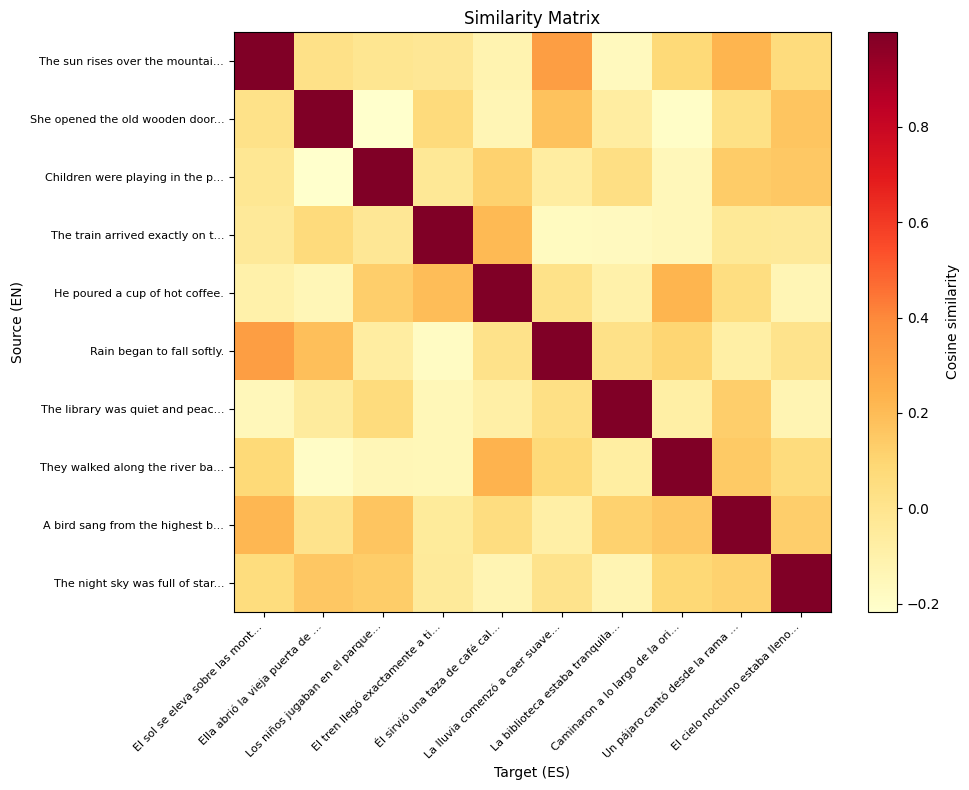

In [5]:
def truncate(s: str, n: int = 30) -> str:
    return s[:n] + "..." if len(s) > n else s


def plot_similarity_heatmap(
    result: AlignmentResult,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    """Plot the similarity matrix as a heatmap."""
    if result.similarity_matrix is None:
        raise ValueError("No similarity matrix — set include_similarity_matrix=True")

    sim = result.similarity_matrix
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(sim, cmap="YlOrRd", aspect="auto", origin="upper")
    plt.colorbar(im, ax=ax, label="Cosine similarity")

    ax.set_xticks(range(len(result.target_sentences)))
    ax.set_xticklabels(
        [truncate(s) for s in result.target_sentences], rotation=45, ha="right", fontsize=8
    )
    ax.set_yticks(range(len(result.source_sentences)))
    ax.set_yticklabels([truncate(s) for s in result.source_sentences], fontsize=8)

    ax.set_xlabel("Target (ES)")
    ax.set_ylabel("Source (EN)")
    ax.set_title("Similarity Matrix")
    return ax


fig, ax = plt.subplots(figsize=(10, 8))
plot_similarity_heatmap(result, ax=ax)
fig.tight_layout()
plt.show()

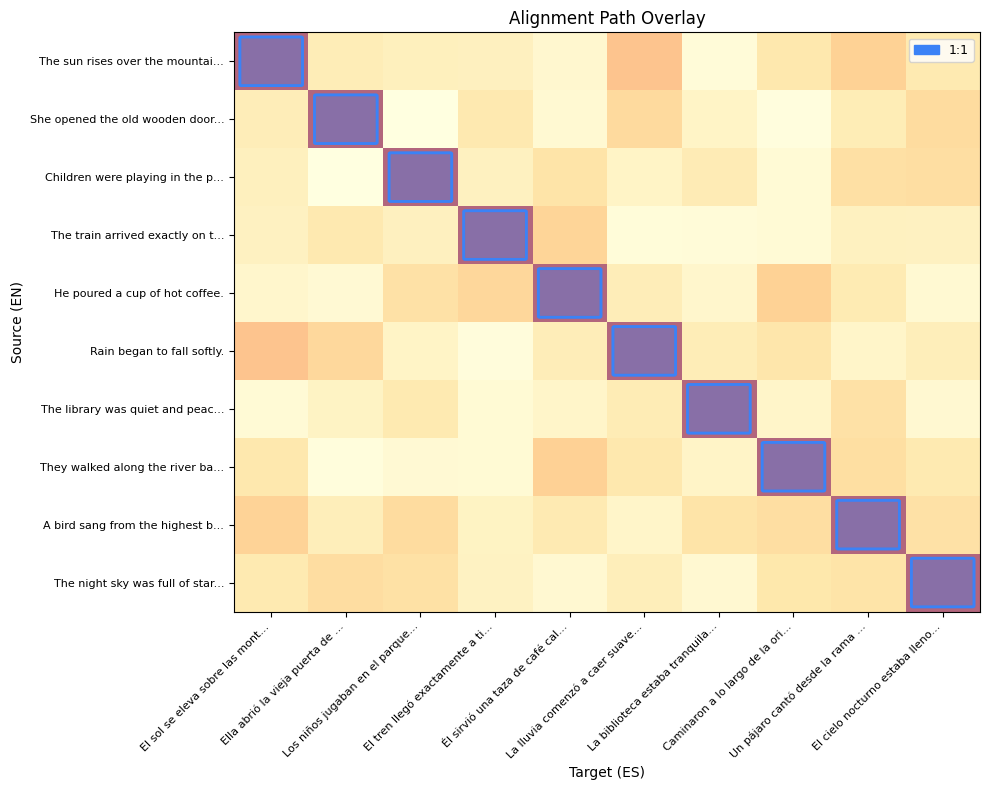

In [6]:
# Color scheme for alignment types
TYPE_COLORS: dict[AlignmentType, str] = {
    AlignmentType.ONE_TO_ONE: "#3b82f6",    # blue
    AlignmentType.TWO_TO_ONE: "#22c55e",    # green
    AlignmentType.ONE_TO_TWO: "#f97316",    # orange
    AlignmentType.TWO_TO_TWO: "#a855f7",    # purple
    AlignmentType.ONE_TO_ZERO: "#ef4444",   # red
    AlignmentType.ZERO_TO_ONE: "#ef4444",   # red
}


def plot_alignment_overlay(
    result: AlignmentResult,
    ax: plt.Axes | None = None,
    title: str = "Alignment Path Overlay",
) -> plt.Axes:
    """Plot the similarity heatmap with the DP alignment path drawn on top."""
    if result.similarity_matrix is None:
        raise ValueError("No similarity matrix — set include_similarity_matrix=True")

    sim = result.similarity_matrix
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))

    ax.imshow(sim, cmap="YlOrRd", aspect="auto", origin="upper", alpha=0.6)

    # Draw alignment rectangles
    for pair in result.pairs:
        color = TYPE_COLORS[pair.alignment_type]

        if pair.source_indices and pair.target_indices:
            y_min = min(pair.source_indices) - 0.4
            y_max = max(pair.source_indices) + 0.4
            x_min = min(pair.target_indices) - 0.4
            x_max = max(pair.target_indices) + 0.4
        elif pair.source_indices:  # 1:0 skip
            y_min = min(pair.source_indices) - 0.4
            y_max = max(pair.source_indices) + 0.4
            x_min = -0.8
            x_max = -0.2
        else:  # 0:1 skip
            y_min = -0.8
            y_max = -0.2
            x_min = min(pair.target_indices) - 0.4
            x_max = max(pair.target_indices) + 0.4

        rect = mpatches.FancyBboxPatch(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            boxstyle="round,pad=0.02",
            facecolor=color,
            edgecolor=color,
            alpha=0.35,
            linewidth=2,
        )
        ax.add_patch(rect)
        # Solid border
        border = mpatches.FancyBboxPatch(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            boxstyle="round,pad=0.02",
            facecolor="none",
            edgecolor=color,
            linewidth=2,
        )
        ax.add_patch(border)

    ax.set_xticks(range(len(result.target_sentences)))
    ax.set_xticklabels(
        [truncate(s) for s in result.target_sentences], rotation=45, ha="right", fontsize=8
    )
    ax.set_yticks(range(len(result.source_sentences)))
    ax.set_yticklabels([truncate(s) for s in result.source_sentences], fontsize=8)

    ax.set_xlabel("Target (ES)")
    ax.set_ylabel("Source (EN)")
    ax.set_title(title)

    # Legend
    seen_types = {p.alignment_type for p in result.pairs}
    legend_handles = [
        mpatches.Patch(color=TYPE_COLORS[t], label=t.value)
        for t in AlignmentType
        if t in seen_types
    ]
    ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    return ax


fig, ax = plt.subplots(figsize=(10, 8))
plot_alignment_overlay(result, ax=ax)
fig.tight_layout()
plt.show()

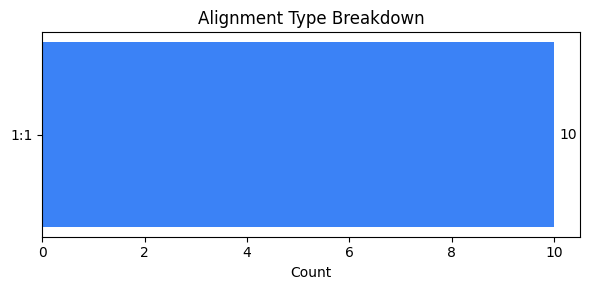

In [7]:
from collections import Counter


def plot_type_breakdown(result: AlignmentResult, ax: plt.Axes | None = None) -> plt.Axes:
    """Horizontal bar chart of alignment type counts."""
    counts = Counter(p.alignment_type for p in result.pairs)
    # Fixed order so charts are comparable
    types = [t for t in AlignmentType if counts.get(t, 0) > 0]
    values = [counts[t] for t in types]
    colors = [TYPE_COLORS[t] for t in types]
    labels = [t.value for t in types]

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 3))

    ax.barh(labels, values, color=colors)
    ax.set_xlabel("Count")
    ax.set_title("Alignment Type Breakdown")
    ax.invert_yaxis()

    for i, v in enumerate(values):
        ax.text(v + 0.1, i, str(v), va="center", fontsize=10)

    return ax


fig, ax = plt.subplots(figsize=(6, 3))
plot_type_breakdown(result, ax=ax)
fig.tight_layout()
plt.show()

## Unequal Lengths: 7 EN to 10 ES

When the source and target have different numbers of sentences, the aligner must introduce
**merges** (grouping multiple sentences on one side) or **skips** (dropping unmatched sentences).

Below we align only the first 7 English sentences against all 10 Spanish ones.

#    Type    Score   English                                       Spanish
------------------------------------------------------------------------------------------------------------------------
0    1:1     0.987   The sun rises over the mountains.             El sol se eleva sobre las montañas.
1    1:1     0.988   She opened the old wooden door.               Ella abrió la vieja puerta de madera.
2    1:1     0.992   Children were playing in the park.            Los niños jugaban en el parque.
3    1:1     0.991   The train arrived exactly on time.            El tren llegó exactamente a tiempo.
4    1:1     0.987   He poured a cup of hot coffee.                Él sirvió una taza de café caliente.
5    1:1     0.989   Rain began to fall softly.                    La lluvia comenzó a caer suavemente.
6    1:1     0.992   The library was quiet and peaceful.           La biblioteca estaba tranquila y pacífica.
7    0:1     0.000   (skip)                                        Caminaron

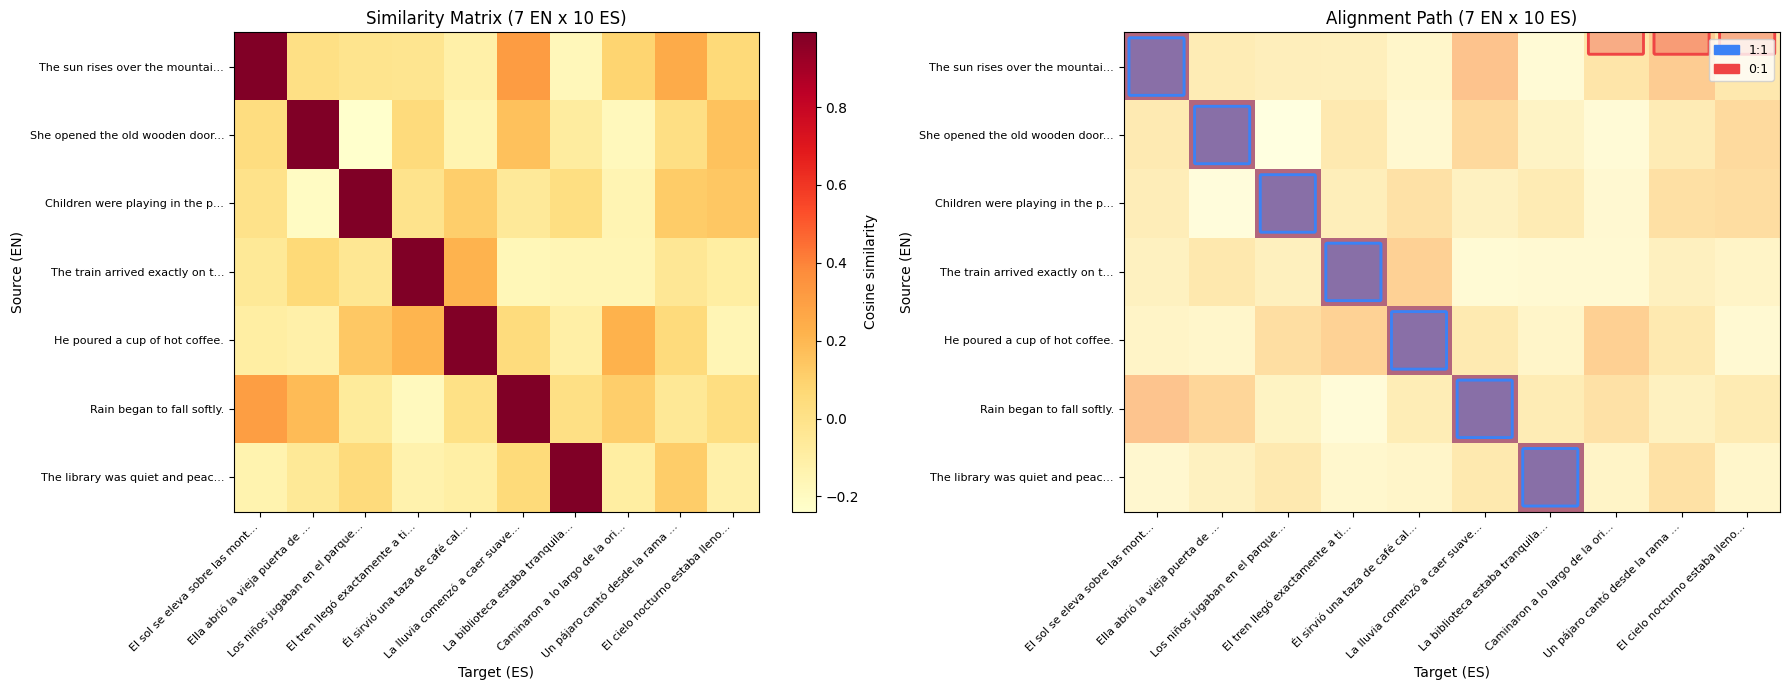

In [8]:
en_short = en[:7]

model2 = PairedEmbedder(n_pairs=len(en_short) + len(es), dim=64, noise=0.1)
cfg2 = AlignConfig(window=50, include_similarity_matrix=True)
result2 = align(en_short, es, config=cfg2, model=model2)

# Print alignment table
print(f"{'#':<4} {'Type':<6} {'Score':>6}   {'English':<45} {'Spanish'}")
print("-" * 120)
for i, pair in enumerate(result2.pairs):
    src = " | ".join(en_short[j] for j in pair.source_indices) or "(skip)"
    tgt = " | ".join(es[j] for j in pair.target_indices) or "(skip)"
    print(f"{i:<4} {pair.alignment_type.value:<6} {pair.score:>6.3f}   {src:<45} {tgt}")

print(f"\nTypes: {[p.alignment_type.value for p in result2.pairs]}")

# Heatmap with overlay
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plot_similarity_heatmap(result2, ax=axes[0])
axes[0].set_title("Similarity Matrix (7 EN x 10 ES)")
plot_alignment_overlay(result2, ax=axes[1], title="Alignment Path (7 EN x 10 ES)")
fig.tight_layout()
plt.show()

## Tuning Parameters

The DP alignment behavior is controlled by `DPConfig`:

| Parameter | Default | Effect |
|-----------|---------|--------|
| `skip_penalty` | -0.3 | Cost of leaving a sentence unmatched (1:0 or 0:1). More negative = fewer skips. |
| `merge_penalty` | -0.05 | Cost of merging sentences (2:1, 1:2, 2:2). More negative = fewer merges. |
| `band_width` | 50 | DP search band half-width around the diagonal. Larger = slower but handles more reordering. |

Below we compare different `skip_penalty` values on the same 7:10 alignment to see how
the aligner trades off skips vs. merges.

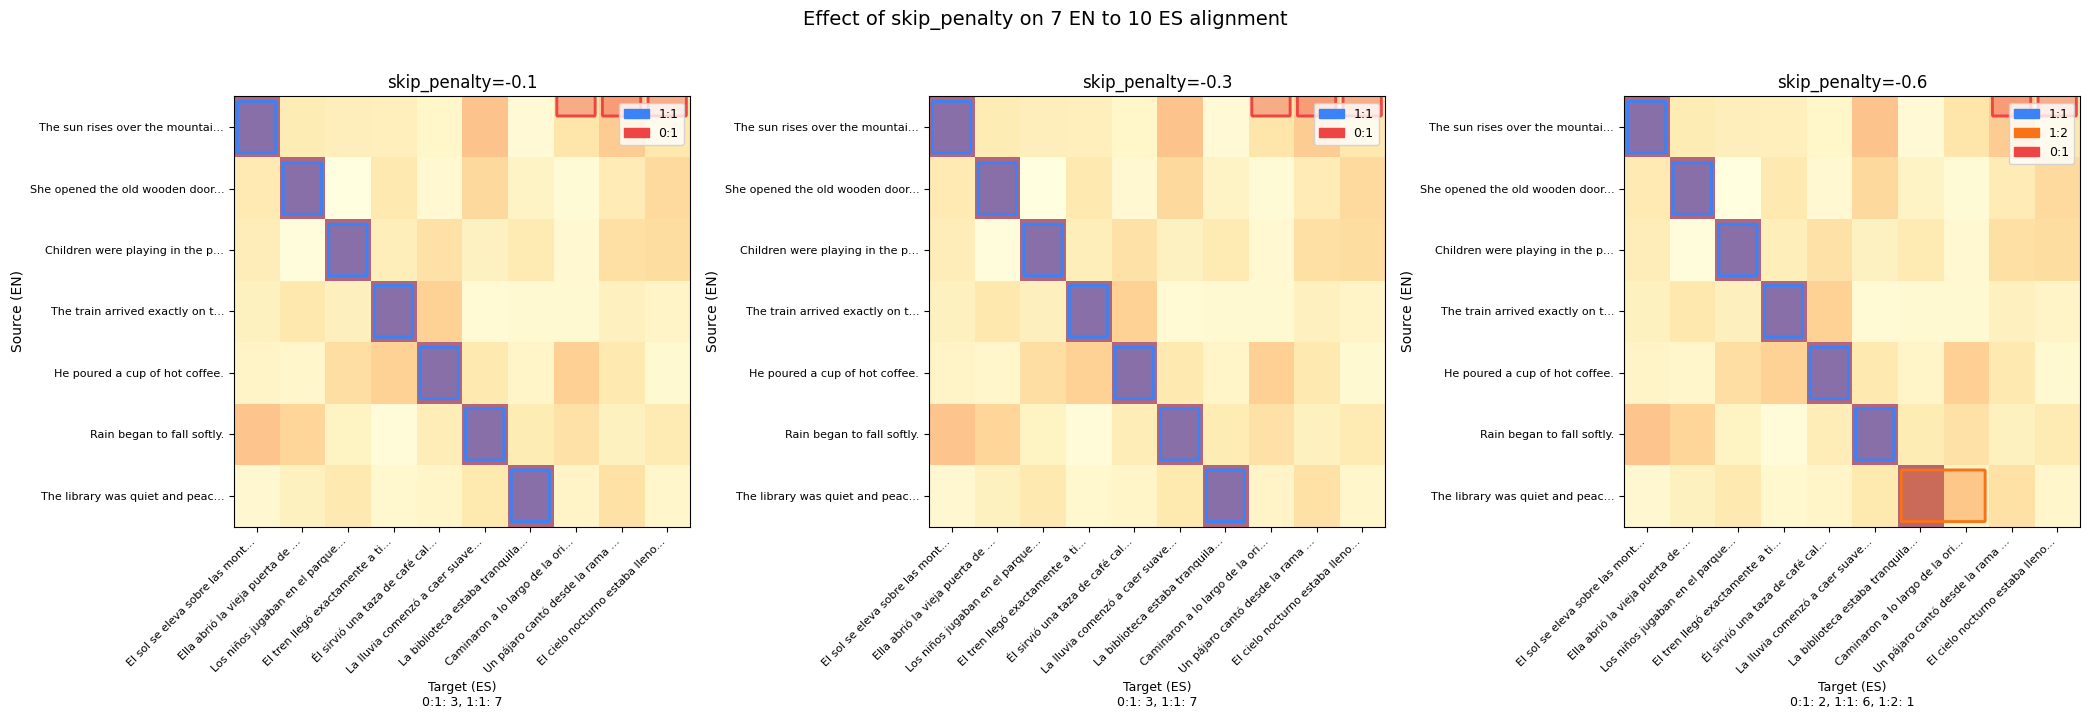

In [9]:
penalties = [-0.1, -0.3, -0.6]
fig, axes = plt.subplots(1, len(penalties), figsize=(7 * len(penalties), 7))

for ax, penalty in zip(axes, penalties):
    model_p = PairedEmbedder(n_pairs=len(en_short) + len(es), dim=64, noise=0.1)
    cfg_p = AlignConfig(
        window=50,
        include_similarity_matrix=True,
        dp=DPConfig(skip_penalty=penalty),
    )
    res = align(en_short, es, config=cfg_p, model=model_p)

    plot_alignment_overlay(res, ax=ax, title=f"skip_penalty={penalty}")

    type_counts = Counter(p.alignment_type for p in res.pairs)
    summary = ", ".join(f"{t.value}: {c}" for t, c in sorted(type_counts.items(), key=lambda x: x[0].value))
    ax.set_xlabel(f"Target (ES)\n{summary}", fontsize=9)

fig.suptitle("Effect of skip_penalty on 7 EN to 10 ES alignment", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()